In [1]:
# In your first Jupyter cell
import numpy as np
import pandas as pd
from aicsimageio import AICSImage
import matplotlib.pyplot as plt

from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label
from skimage.measure import regionprops_table
from skimage.morphology import remove_small_objects
import plotly.graph_objects as go
from skimage.measure import marching_cubes
import scipy.ndimage

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="skimage.measure._regionprops")

## Loading the 3D Image Data

In [3]:
def load_ome_tiff(filepath):
    """
    Loads a 3D OME-TIFF image and its metadata.

    Args:
        filepath (str): The path to the OME-TIFF file.

    Returns:
        tuple: A tuple containing the 3D image data as a NumPy array
               and a tuple of the physical pixel sizes (Z, Y, X).
    """
    # Create an AICSImage object to handle the file and its metadata
    img_object = AICSImage(filepath)
    
    # Load the core image data into a NumPy array.
    # We specify "ZYX" to get the 3D stack.
    # T=0, C=0 assumes we want the first timepoint and first channel.
    image_data_3d = img_object.get_image_data("ZYX", T=0, C=0)
    
    # Extract physical pixel sizes for accurate measurements.
    pixel_sizes = (
        img_object.physical_pixel_sizes.Z,
        img_object.physical_pixel_sizes.Y,
        img_object.physical_pixel_sizes.X
    )
    
    print(f"Image loaded successfully!")
    print(f"Image dimensions (Z, Y, X): {image_data_3d.shape}")
    print(f"Pixel sizes (µm) (Z, Y, X): {pixel_sizes}")
    
    return image_data_3d, pixel_sizes

## Visualization Step: Inspecting the Raw Data

In [4]:
def visualize_slices(image_3d, title_prefix=""):
    """
    Displays the middle Z-slice and a maximum intensity Z-projection.
    """
    middle_z_index = image_3d.shape[0] // 2
    max_projection = np.max(image_3d, axis=0)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(image_3d[middle_z_index], cmap='gray')
    axes[0].set_title(f"{title_prefix} - Middle Z-Slice (Z={middle_z_index})")
    axes[0].axis('off')
    
    axes[1].imshow(max_projection, cmap='gray')
    axes[1].set_title(f"{title_prefix} - Max Intensity Projection")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## Segmentation: Isolating Biofilm Structures

In [5]:
def segment_image(image_3d):
    """
    Segments the 3D image to identify individual objects.

    Args:
        image_3d (np.ndarray): The 3D image data.

    Returns:
        np.ndarray: A labeled image where each object has a unique integer ID.
    """
    # 1. Smooth the image to reduce noise
    print("Applying Gaussian filter...")
    smoothed_image = gaussian(image_3d, sigma=1)
    
    # 2. Determine an automatic threshold using Otsu's method
    print("Calculating threshold...")
    thresh = threshold_otsu(smoothed_image)
    
    # 3. Create a binary mask
    binary_mask = smoothed_image > thresh
    
    # 4. Label connected regions to identify individual objects
    print("Labeling objects...")
    labeled_image, num_objects = label(binary_mask, return_num=True)
    
    print(f"Segmentation complete. Found {num_objects} objects.")
    return labeled_image

In [6]:
def visualize_segmentation(original_image, labeled_image):
    """
    Visualizes the segmentation result on the middle Z-slice.
    """
    middle_z_index = original_image.shape[0] // 2
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    ax.imshow(original_image[middle_z_index], cmap='gray', alpha=0.8)
    # Use a color map that shows labels clearly. 'jet' or 'nipy_spectral' work well.
    # We set background (label 0) to be transparent.
    ax.imshow(labeled_image[middle_z_index], cmap='nipy_spectral', alpha=0.5, vmin=1) 
    ax.set_title("Segmentation Overlay - Middle Z-Slice")
    ax.axis('off')
    plt.show()

In [7]:
def interpolate_z_axis(labeled_image, pixel_sizes, upsample_factor=10):
    """
    Upsamples a 3D image along the Z-axis to allow for smooth meshing.

    This function is crucial for visualizations where the Z-resolution is much lower
    than the XY-resolution, preventing the "pillar" or "stack of pancakes" look.

    Args:
        labeled_image (np.ndarray): The labeled 3D image.
        pixel_sizes (tuple): The original (Z, Y, X) physical pixel sizes.
        upsample_factor (int): How many new slices to create between original slices.
                               A factor of 10 is a good starting point.

    Returns:
        tuple: A tuple containing:
            - interpolated_image (np.ndarray): The upsampled labeled image.
            - new_pixel_sizes (tuple): The new, corrected pixel sizes for the upsampled image.
    """
    print(f"Original labeled image shape: {labeled_image.shape}")
    print(f"Original pixel sizes (Z,Y,X): {pixel_sizes}")
    print(f"Interpolating Z-axis by a factor of {upsample_factor}...")

    # Define the zoom factors for each axis (Z, Y, X)
    zoom_factors = (upsample_factor, 1, 1)

    # Perform the zoom. We use order=0 (nearest neighbor) because we are resampling
    # integer labels. Any other method would create incorrect float values between objects.
    interpolated_image = scipy.ndimage.zoom(labeled_image, zoom_factors, order=0)

    # Calculate the new pixel sizes. The Z-dimension is now denser.
    new_pixel_sizes = (
        pixel_sizes[0] / upsample_factor,
        pixel_sizes[1],
        pixel_sizes[2]
    )
    
    print(f"Interpolation complete.")
    print(f"New interpolated image shape: {interpolated_image.shape}")
    print(f"New pixel sizes (Z,Y,X): {new_pixel_sizes}")
    
    return interpolated_image, new_pixel_sizes

In [8]:
def calculate_statistics(labeled_image, intensity_image, pixel_sizes):
    """
    Calculates quantitative metrics for each labeled object.

    Args:
        labeled_image (np.ndarray): The image with labeled objects.
        intensity_image (np.ndarray): The original grayscale image.
        pixel_sizes (tuple): The (Z, Y, X) physical pixel sizes.

    Returns:
        pd.DataFrame: A DataFrame containing metrics for each object.
    """
    # Define which properties to measure for each object
    properties_to_measure = (
        'label', 'area', 'equivalent_diameter', 
        'mean_intensity', 'max_intensity', 'solidity'
    )
    
    print("Calculating region properties...")
    # Calculate properties. This returns a dictionary of columns.
    props_table = regionprops_table(
        labeled_image,
        intensity_image=intensity_image,
        properties=properties_to_measure
    )
    
    # Convert to a pandas DataFrame for easier manipulation
    df = pd.DataFrame(props_table)
    
    # --- Calculate metrics in physical units ---
    # The 'area' from regionprops is the volume in voxels for 3D images
    voxel_volume = pixel_sizes[0] * pixel_sizes[1] * pixel_sizes[2]
    df['volume_um3'] = df['area'] * voxel_volume
    df['equivalent_diameter_um'] = df['equivalent_diameter'] * np.mean(pixel_sizes[1:])
    
    print("Metrics calculation complete.")
    return df

In [9]:
def filter_small_objects(labeled_image, min_size_voxels=20):
    """
    Removes small, noisy objects from a labeled image.

    Args:
        labeled_image (np.ndarray): The image with labeled objects.
        min_size_voxels (int): The minimum number of voxels an object must have to be kept.

    Returns:
        np.ndarray: A cleaned labeled image.
    """
    print(f"Removing objects smaller than {min_size_voxels} voxels...")
    
    # This function directly removes the objects from the labeled array.
    cleaned_labeled_image = remove_small_objects(labeled_image, min_size=min_size_voxels)
    
    # Let's see how many objects we removed
    original_object_count = len(np.unique(labeled_image)) - 1 # -1 for background
    cleaned_object_count = len(np.unique(cleaned_labeled_image)) - 1
    
    print(f"Filtered out {original_object_count - cleaned_object_count} objects.")
    print(f"Remaining objects: {cleaned_object_count}")
    
    return cleaned_labeled_image

## Interactive 3D mesh plot

In [10]:
def create_3d_visualization_fast(labeled_image, stats_df, pixel_sizes, color_by_metric='volume_um3', step_size=4):
    """
    Generates an efficient 3D mesh plot and saves it to HTML and PNG files.

    Args:
        labeled_image (np.ndarray): The labeled image data.
        stats_df (pd.DataFrame): DataFrame with stats.
        pixel_sizes (tuple): The (Z, Y, X) physical pixel sizes.
        color_by_metric (str): The column in stats_df to use for color-coding.
        step_size (int): Downsampling factor for mesh generation. Higher is faster but less detailed.
                         Given your image size, a step_size of 4 or even 6 is recommended.
    """
    print(f"Generating 3D mesh with a step size of {step_size}. This will be much faster.")
    
    try:
        # Generate a single mesh from the entire labeled volume.
        verts, faces, normals, values = marching_cubes(
            labeled_image,
            level=0,
            spacing=pixel_sizes,
            step_size=step_size  # Crucial for performance on large images!
        )
    except (RuntimeError, ValueError) as e:
        print(f"Mesh generation failed. Error: {e}")
        return

    # Map label IDs from the mesh vertices to the metric values (e.g., volume)
    label_to_metric = pd.Series(stats_df[color_by_metric].values, index=stats_df.label).to_dict()
    vertex_colors = np.array([label_to_metric.get(v, 0) for v in values])

    # Create the Plotly Mesh3d object
    mesh = go.Mesh3d(
        x=verts[:, 2], y=verts[:, 1], z=verts[:, 0], # Marching cubes is ZYX, Plotly is XYZ
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        intensity=vertex_colors,
        colorscale='Viridis',
        colorbar_title=color_by_metric,
        showscale=True,
        name='Biofilms'
    )

    # Configure the layout
    fig = go.Figure(data=[mesh])
    fig.update_layout(
        title='3D Color-Coded Biofilm Visualization (Optimized)',
        scene=dict(
            xaxis_title='X (µm)',
            yaxis_title='Y (µm)',
            zaxis_title='Z (µm)',
            aspectmode='data' # This ensures the physical aspect ratio is correct
        )
    )
    
    # --- SAVE AND SHOW ---
    # 1. Save to an interactive HTML file
    html_filename = 'biofilm_visualization.html'
    fig.write_html(html_filename)
    print(f"\n---> Interactive plot saved to: {html_filename}")
    print("     You can download this file and open it in your web browser.")

    # 2. Save to a static PNG image file
    # png_filename = 'biofilm_visualization.png'
    # try:
    #     fig.write_image(png_filename, width=1200, height=800, scale=2)
    #     print(f"---> Static PNG image saved to: {png_filename}")
    # except Exception as e:
    #     print(f"\nCould not save PNG image. The 'kaleido' package might be missing or misconfigured.")
    #     print(f"Install it by running: pip install kaleido")
    #     print(f"Error details: {e}")

    # 3. Try to display in the notebook
    print("\nDisplaying interactive plot in notebook (if environment supports it)...")
    fig.show()

## Pipeline

In [11]:
# 1. Load the image (as before)
FILE_PATH = 'PhC_RFP_100x_Third_16h_No_Cleaning_Stacking_162_CF_1_MMStack_Pos0.ome.tif' 
raw_image, pixel_sizes = load_ome_tiff(FILE_PATH)

# 2. Segment the image to find objects (as before)
labeled_biofilms = segment_image(raw_image)

Image loaded successfully!
Image dimensions (Z, Y, X): (81, 2304, 2304)
Pixel sizes (µm) (Z, Y, X): (2.0, 0.065, 0.065)
Applying Gaussian filter...
Calculating threshold...
Labeling objects...
Segmentation complete. Found 2020 objects.


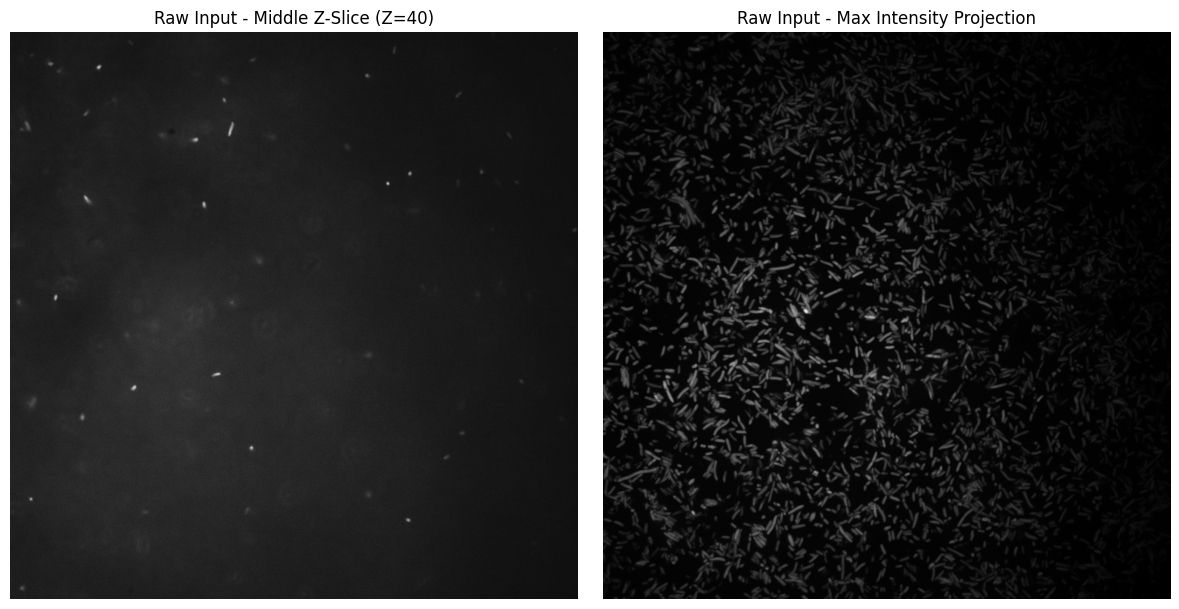

In [12]:
visualize_slices(raw_image, title_prefix="Raw Input")

Applying Gaussian filter...
Calculating threshold...
Labeling objects...
Segmentation complete. Found 2020 objects.


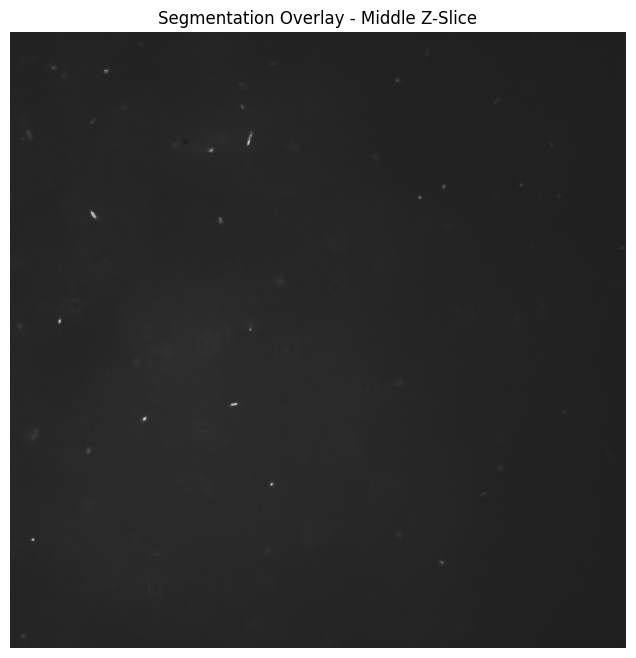

In [13]:
# Perform segmentation
labeled_biofilms = segment_image(raw_image)
visualize_segmentation(raw_image, labeled_biofilms)

In [14]:
# 3. Clean the segmentation result by removing tiny objects (as before)
cleaned_labels = filter_small_objects(labeled_biofilms, min_size_voxels=50) # min_size may need adjustment

Removing objects smaller than 50 voxels...
Filtered out 271 objects.
Remaining objects: 1749


In [15]:
# 4. Calculate statistics on the CLEANED (but non-interpolated) data
# It's faster and more accurate to do this on the original data.
biofilm_stats = calculate_statistics(cleaned_labels, raw_image, pixel_sizes)

Calculating region properties...


/usr/local/lib/python3.11/site-packages/skimage/measure/_regionprops.py:675: RuntimeWarning: divide by zero encountered in scalar divide
  return self.area / self.area_convex


Metrics calculation complete.


In [16]:
# 5. We use the 'cleaned_labels' array for this step.
# A factor of 10 should give a good result without using excessive memory.
interpolated_labels, interpolated_pixel_sizes = interpolate_z_axis(
    cleaned_labels, 
    pixel_sizes, 
    upsample_factor=10
)

Original labeled image shape: (81, 2304, 2304)
Original pixel sizes (Z,Y,X): (2.0, 0.065, 0.065)
Interpolating Z-axis by a factor of 10...
Interpolation complete.
New interpolated image shape: (810, 2304, 2304)
New pixel sizes (Z,Y,X): (0.2, 0.065, 0.065)


In [ ]:
# 6. Visualize the INTERPOLATED data
# CRITICAL: We must pass the NEW interpolated_labels and interpolated_pixel_sizes
# to the visualization function to get the correct shape and smoothness.
# A smaller step_size can be used now because the Z-axis is denser.
create_3d_visualization_fast(
    interpolated_labels,
    biofilm_stats,
    interpolated_pixel_sizes,  # <-- Use the new pixel sizes
    color_by_metric='volume_um3',
    step_size=2  # <-- Can use a smaller step_size for more detail now
)

Generating 3D mesh with a step size of 2. This will be much faster.
